In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import random

In [2]:
class Value:
    def __init__(self, data, _children = (), _op= '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda : None
        self.grad = 0.0
        self.label = label
    
    def __repr__(self):
        return f"Value(data = {self.data})"
    
    #Gradients need to be accumulated, as if not, when you use a variable more than once, the gradients become
    # incorrect.
    def __add__(self, other):
        # If the second variable is not a "Value" object, convert it to one via the isinstance method.
        if(isinstance(other, Value) != True):
            other = Value(other)

        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        if(isinstance(other, Value) != True):
            other = Value(other)
        out = Value(self.data*other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    # If isinstance(self, Value) == False, and python for some reason cannot execute the mul function,
    # it uses __rmul__ as fall back and simply swaps the function arguments.
    def __rmul__(self, other):
        return self * other
    
    
    def __truediv__(self, other):
        return (self*(other**-1))
    def __sub__(self, other):
        return (self + (-1)*other)
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n)-1)/(math.exp(2*n)+1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1-t**2)*out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += ((out.grad)*(out.data))
        out._backward = _backward
        return out
    
    def __pow__(self, power):
        x = self.data
        out = Value(x**power, (self, ), '^')
        def _backward():
            self.grad += ((power*(x**(power-1)))*out.grad)
        out._backward = _backward
        return out
    
    #Implemented a backward function using topological sort, that runs the ._backward() function attribute of 
    # an object in reverse topological order, so as to propagate the gradient values correctly.
    def backward(self):
        topo =[]
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self) 
        self.grad = 1.0
        topo.reverse()
        for num in topo:
            num._backward()

In [3]:
from graphviz import Digraph

#Digraph library, used for representing neural nets.
#First function is a simple graph building function, the second one uses nodes, as data-points and 

def trace(root):
    """Walk the graph backward from `root`, collecting every node and edge."""
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root, format='svg', rankdir='LR'):
    """
    Render the computation graph rooted at `root`.
    format:  'svg' | 'png' | ...   (svg is crisp in notebooks)
    rankdir: 'LR' (left-to-right) | 'TB' (top-to-bottom)
    """
    assert rankdir in ('LR', 'TB')
    nodes, edges = trace(root)

    dot = Digraph(
        format=format,
        graph_attr={'rankdir': rankdir},
    )

    for n in nodes:
        # each Value gets a rectangular "record" node showing label | data | grad
        dot.node(
            name=str(id(n)),
            label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape='record',
        )
        # if this Value was produced by an operation, add an op node and wire it in
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    for n1, n2 in edges:
        # connect n1 to the op node that produced n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

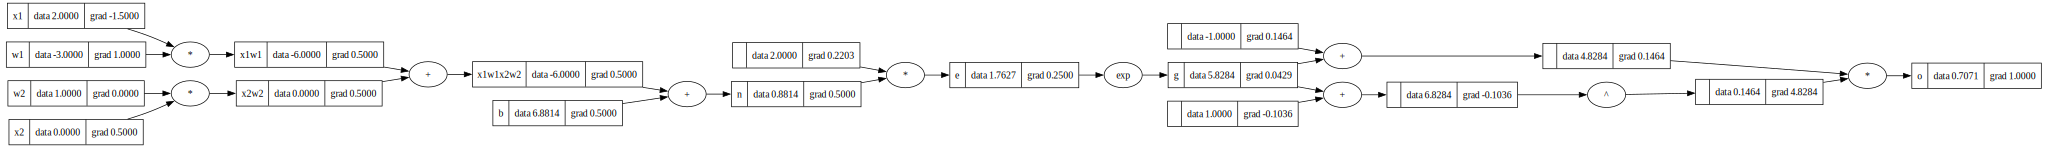

In [4]:
h = 0.0001

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = "x2")
w1 = Value(-3.0, label ="w1")
w2 = Value(1.0, label = "w2")
b = Value(6.8813735870195432, label = "b")
x1w1 = x1*w1; x1w1.label = "x1w1"
x2w2 = x2*w2;  x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1x2w2"
n = x1w1x2w2 + b; n.label = "n"
e = (2*n); e.label = 'e'
g = (e).exp(); g.label = 'g'
o = ((g-1)/(g+1)); o.label = 'o'
o.backward()
draw_dot(o)

In [5]:
torch.Tensor([2.0]).double().dtype

torch.float64

In [6]:
# By default requires gradient for a LEAF NODE is set to false in PyTorch for efficiency reasons, 
# which is why we must turn them on now.

# .double() casts a tensor (a multi dimensional array) to 64 bit double from a 32 bit float


x1 = torch.Tensor([2.0]).double();               x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();               x2.requires_grad = True   
w1 = torch.Tensor([-3.0]).double();              w1.requires_grad = True   
w2 = torch.Tensor([1.0]).double();               w2.requires_grad = True   
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True   
n = x1*w1 + x2*w2 + b;  # Cannot change gradient of a non leaf node!!                            
o = torch.tanh(n)
o.backward()

# .data.item() extracts the singular value out of the tensor which contains only one element.
print(o.data.item())
print(w2.grad.item())
print(x2.grad.item())
print(x1.grad.item())
print(b.grad.item())


0.7071066904050358
0.0
0.5000001283844369
-1.5000003851533106
0.5000001283844369


In [ ]:
# zip just puts the two lists together, so you can iterate over them as pairs of tuples


class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for i in range(nin)]
        self.b = (Value(random.uniform(-1, 1)))
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for i in range(nout)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if (len(outs)==1) else outs

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    

x = [2.0, 3.0, -1.0]

n = MLP(3, [4,4,1])
n(x)

Value(data = 0.4864824818062736)

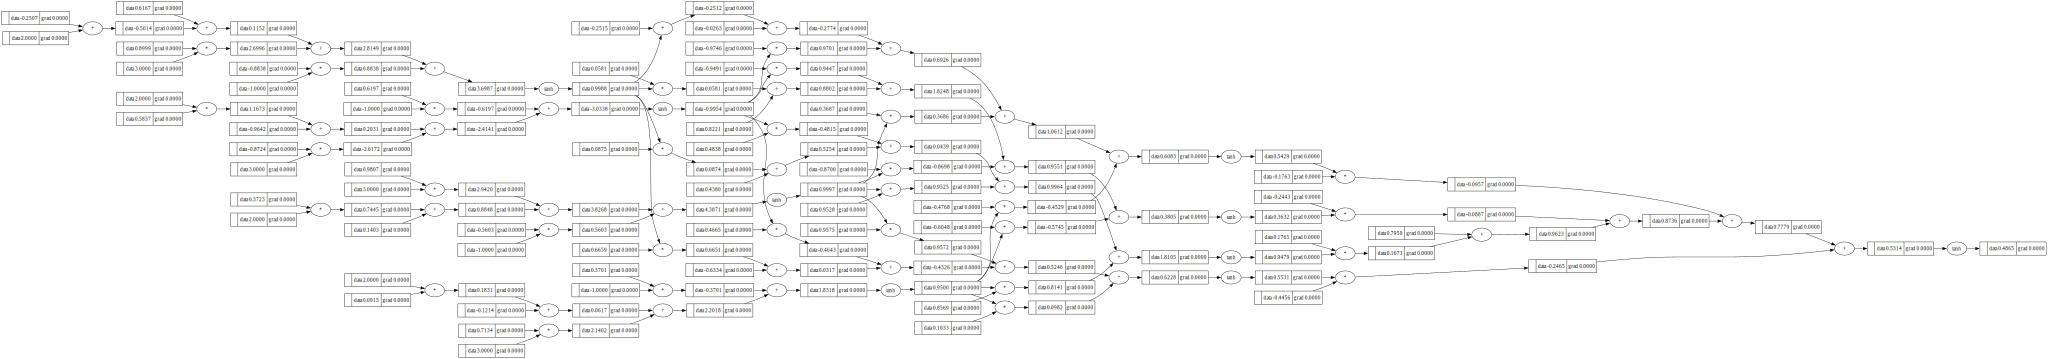

In [16]:
draw_dot(n(x))

In [29]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  #Desired Targets

ypreds = [n(x).data for x in xs]
ypreds

[0.4864824818062736, 0.8489288655182172, 0.635132731094263, 0.4209741202791547]

In [30]:
loss = 0
[(ygt-ypred)**2 for ygt, ypred in zip(ys, ypreds)]

[0.2637002414918441, 3.4185379497464816, 2.673659048295783, 0.3352709693864988]